# 📈 Stock Pipeline — Visual Analysis
**Reads directly from PostgreSQL** | Run cells top to bottom

| Cell | What it shows |
|------|---------------|
| 1 | DB connection + helper |
| 2 | Latest prices table (colour coded) |
| 3 | Normalised price history |
| 4 | Moving averages for any ticker |
| 5 | RSI heatmap |
| 6 | Volatility bar chart |
| 7 | Correlation matrix |
| 8 | Custom SQL playground |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine, text

# ── Import credentials from your secure config ──────────────
from config import DB_CONFIG

engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

def q(sql, params=None):
    """Run a SQL query and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":"#0d0d1a", "axes.facecolor":"#13132a",
    "axes.edgecolor":"#2a2a50",   "axes.labelcolor":"#c8c8e8",
    "xtick.color":"#c8c8e8",       "ytick.color":"#c8c8e8",
    "text.color":"#ffffff",         "grid.color":"#252545",
    "grid.linestyle":"--",           "legend.facecolor":"#1a1a38",
    "legend.edgecolor":"#2a2a50",   "font.size":11,
})
COLORS = ["#6c8eff","#ffb347","#3de0c0","#ff6b6b","#c3ff6b",
          "#ff69b4","#69b4ff","#ffe769","#cc69ff","#69ffc3"]

# Quick connection test
try:
    count = q("SELECT COUNT(*) AS n FROM stock_prices").iloc[0]["n"]
    print(f"✅ Connected to PostgreSQL  |  stock_prices rows: {count:,}")
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("   Check your password / dbname / host in the config above.")

✅ Connected to PostgreSQL  |  stock_prices rows: 616


In [2]:
# ── CELL 2 — Latest Prices Table ─────────────────────────────────────────────
latest = q("""
    SELECT
        lp.ticker,
        lp.date,
        ROUND(lp.close::NUMERIC, 2)                 AS close,
        ROUND((sm.daily_return * 100)::NUMERIC, 2)  AS daily_ret_pct,
        ROUND(sm.sma_10::NUMERIC, 2)                AS sma_10,
        ROUND(sm.sma_50::NUMERIC, 2)                AS sma_50,
        ROUND(sm.rsi_14::NUMERIC, 1)                AS rsi_14,
        ROUND((sm.volatility_30d * 100)::NUMERIC, 2) AS vol_30d_pct
    FROM latest_prices lp
    LEFT JOIN stock_metrics sm USING (ticker, date)
    ORDER BY lp.ticker
""")

def c_rsi(v):
    if pd.isna(v): return ""
    return "background:#7a1f1f;color:white" if v>=70 else ("background:#1a5c2e;color:white" if v<=30 else "")

def c_ret(v):
    return "color:#3de0c0" if (not pd.isna(v) and v>=0) else "color:#ff6b6b"

latest.style \
    .map(c_rsi,  subset=["rsi_14"]) \
    .map(c_ret,  subset=["daily_ret_pct"]) \
    .format({"close":"${:.2f}","daily_ret_pct":"{:+.2f}%",
             "vol_30d_pct":"{:.2f}%","rsi_14":"{:.1f}"}) \
    .set_caption("Latest Prices  |  RSI: 🔴 overbought >70   🟢 oversold <30")

,ticker,date,close,daily_ret_pct,sma_10,sma_50,rsi_14,vol_30d_pct
0,AAPL,2026-04-23,$273.43,+0.10%,266.440000,260.230000,67.0,1.54%
1,AMZN,2026-04-23,$255.08,-0.11%,248.470000,217.440000,94.0,2.07%
2,GOOGL,2026-04-23,$338.89,-0.13%,333.420000,308.890000,82.0,2.10%
3,JPM,2026-04-23,$311.69,-0.42%,311.550000,299.010000,69.4,1.39%
4,META,2026-04-23,$659.15,-2.31%,663.750000,629.730000,76.8,2.99%
5,MSFT,2026-04-23,$415.75,-3.97%,409.350000,393.650000,72.2,1.93%
6,NVDA,2026-04-23,$199.64,-1.41%,197.740000,184.660000,83.3,2.02%
7,RELIANCE.NS,2026-04-23,$1343.40,-1.37%,1346.980000,1389.180000,45.3,1.71%
8,TSLA,2026-04-23,$373.72,-3.56%,378.720000,388.120000,56.0,2.86%
9,V,2026-04-23,$308.88,-0.77%,311.720000,310.740000,60.2,1.24%


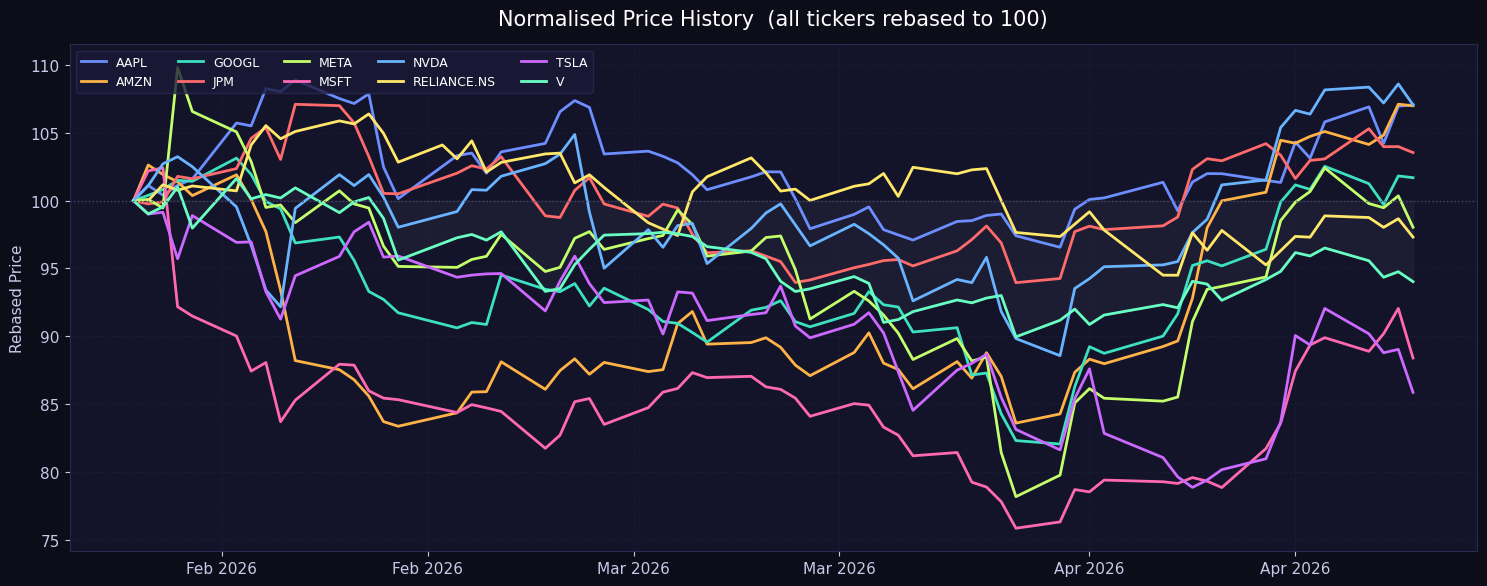

In [3]:
# ── CELL 3 — Normalised Price History ─────────────────────────────────────────
prices = q("SELECT ticker, date, close FROM stock_prices ORDER BY ticker, date")
prices["date"] = pd.to_datetime(prices["date"])

fig, ax = plt.subplots(figsize=(15, 6))
for i, (ticker, grp) in enumerate(prices.groupby("ticker")):
    norm = grp.set_index("date")["close"] / grp["close"].iloc[0] * 100
    ax.plot(norm.index, norm.values, label=ticker,
            color=COLORS[i % len(COLORS)], linewidth=2)

ax.axhline(100, color="#44446a", linewidth=1, linestyle=":")
ax.fill_between(norm.index, 100, norm.values, alpha=0.04, color="white")
ax.set_title("Normalised Price History  (all tickers rebased to 100)", fontsize=15, pad=14)
ax.set_ylabel("Rebased Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(ncol=5, loc="upper left", fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

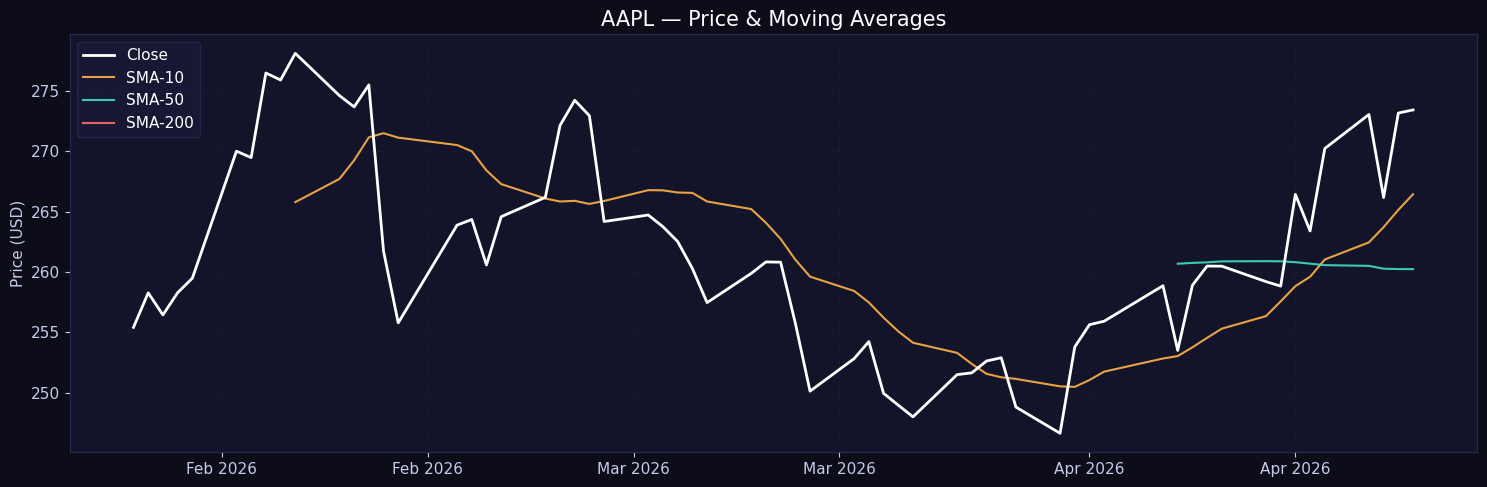

In [4]:
# ── CELL 4 — Moving Averages (change TICKER below) ───────────────────────────
TICKER = "AAPL"    # ← change to any ticker you track

df = q("""
    SELECT date, close, sma_10, sma_50, sma_200
    FROM   price_with_metrics
    WHERE  ticker = :t
    ORDER  BY date
""", params={"t": TICKER})
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df["close"],   color="#ffffff", lw=2,   label="Close",   zorder=5)
ax.plot(df.index, df["sma_10"],  color="#ffb347", lw=1.5, label="SMA-10",  alpha=0.9)
ax.plot(df.index, df["sma_50"],  color="#3de0c0", lw=1.5, label="SMA-50",  alpha=0.9)
ax.plot(df.index, df["sma_200"], color="#ff6b6b", lw=1.5, label="SMA-200", alpha=0.9)

ax.set_title(f"{TICKER} — Price & Moving Averages", fontsize=15)
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

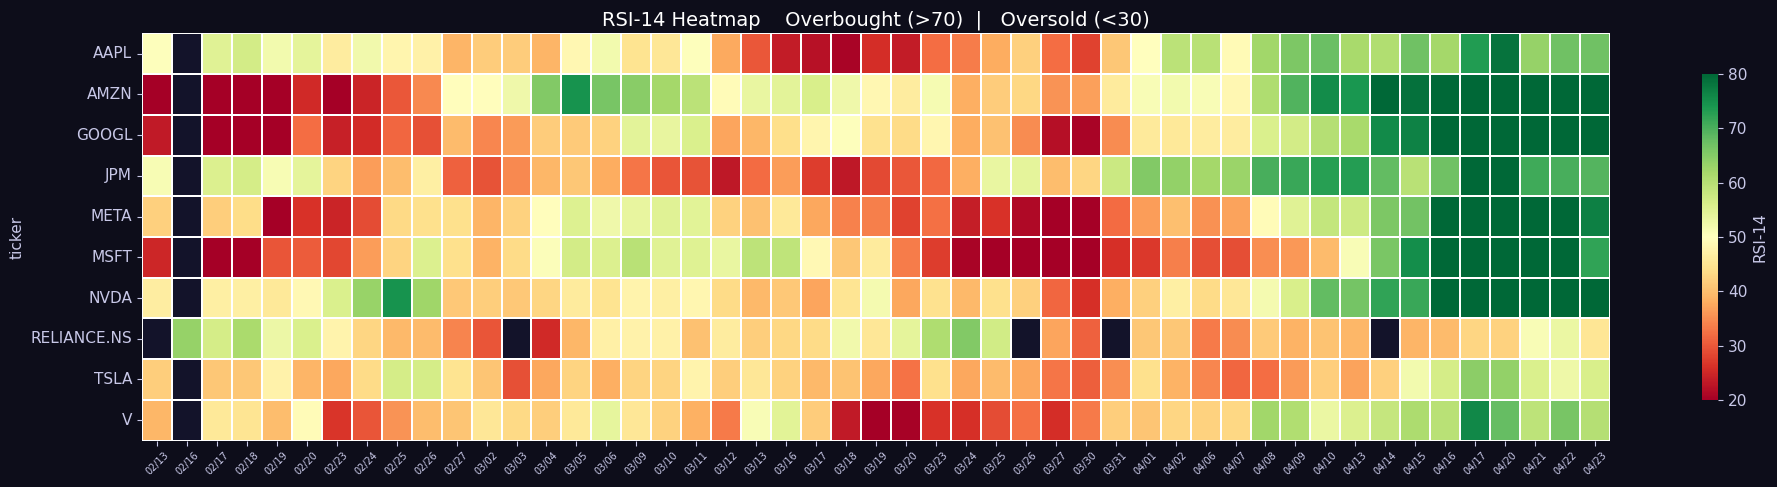

In [5]:
# ── CELL 5 — RSI Heatmap ──────────────────────────────────────────────────────
rsi_df = q("""
    SELECT ticker, date, rsi_14
    FROM   stock_metrics
    WHERE  rsi_14 IS NOT NULL
    ORDER  BY date
""")
rsi_df["date"] = pd.to_datetime(rsi_df["date"])
pivot = rsi_df.pivot(index="ticker", columns="date", values="rsi_14").iloc[:, -60:]
pivot.columns = [d.strftime("%m/%d") for d in pivot.columns]

fig, ax = plt.subplots(figsize=(20, 5))
sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=50, vmin=20, vmax=80,
            linewidths=0.3, annot=False,
            cbar_kws={"label": "RSI-14", "shrink": 0.8})
ax.set_title("RSI-14 Heatmap    Overbought (>70)  |   Oversold (<30)", fontsize=14)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

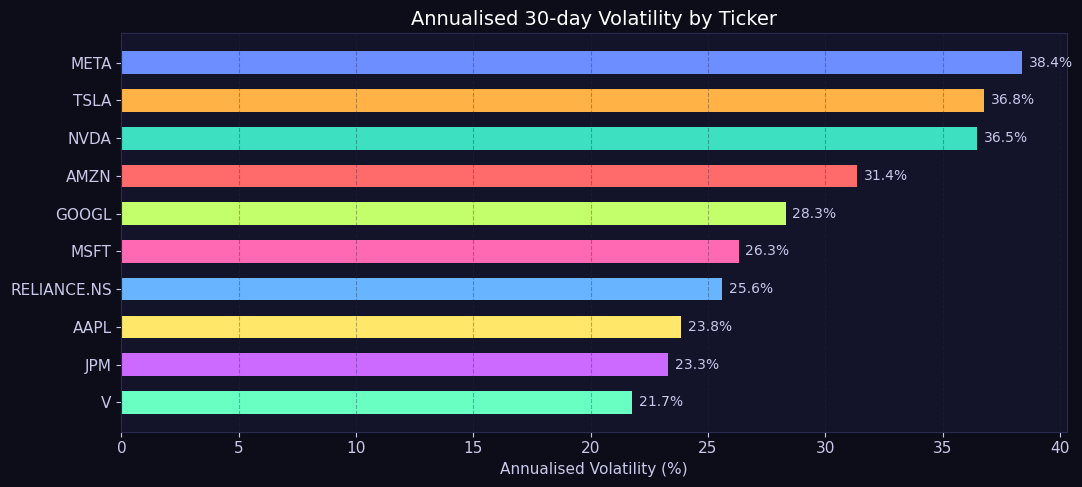

In [6]:
# ── CELL 6 — Annualised Volatility ────────────────────────────────────────────
vol = q("""
    SELECT ticker, AVG(volatility_30d) AS avg_vol
    FROM   stock_metrics
    WHERE  volatility_30d IS NOT NULL
    GROUP  BY ticker
    ORDER  BY avg_vol DESC
""")
vol["ann_vol"] = vol["avg_vol"].astype(float) * (252 ** 0.5) * 100

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(vol["ticker"], vol["ann_vol"],
               color=COLORS[:len(vol)], height=0.6, edgecolor="none")
ax.bar_label(bars, fmt="%.1f%%", padding=5, color="#c8c8e8", fontsize=10)
ax.set_title("Annualised 30-day Volatility by Ticker", fontsize=14)
ax.set_xlabel("Annualised Volatility (%)")
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.35)
plt.tight_layout()
plt.show()

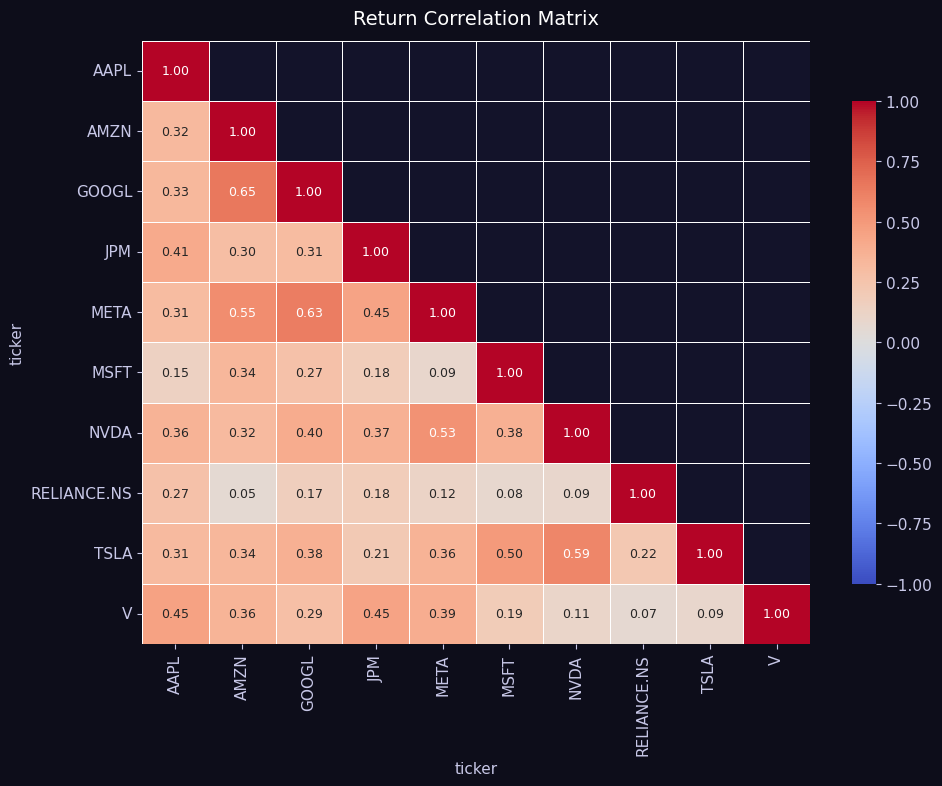

In [7]:
# ── CELL 7 — Return Correlation Matrix ────────────────────────────────────────
rets = q("""
    SELECT ticker, date, daily_return
    FROM   stock_metrics
    WHERE  daily_return IS NOT NULL
""")
pivot_r = rets.pivot(index="date", columns="ticker", values="daily_return").astype(float)
corr    = pivot_r.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Return Correlation Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [8]:
# ── CELL 8 — Custom SQL Playground ────────────────────────────────────────────
# Edit the query below to explore anything you like!
custom = q("""
    SELECT
        ticker,
        ROUND((AVG(daily_return) * 252 * 100)::NUMERIC, 2)  AS annualised_return_pct,
        ROUND(AVG(rsi_14)::NUMERIC, 1)                       AS avg_rsi,
        ROUND(MIN(close)::NUMERIC, 2)                        AS period_low,
        ROUND(MAX(close)::NUMERIC, 2)                        AS period_high,
        COUNT(*)                                              AS trading_days
    FROM price_with_metrics
    WHERE close IS NOT NULL
    GROUP BY ticker
    ORDER BY annualised_return_pct DESC
""")

custom.style \
    .background_gradient(subset=["annualised_return_pct"], cmap="RdYlGn") \
    .format({"annualised_return_pct": "{:+.2f}%", "avg_rsi": "{:.1f}"}) \
    .set_caption("Period Summary — sorted by annualised return")

,ticker,annualised_return_pct,avg_rsi,period_low,period_high,trading_days
0,NVDA,+34.75%,53.3,165.170000,202.500000,62
1,AMZN,+33.31%,53.9,198.790000,255.360000,62
2,AAPL,+31.52%,48.1,246.630000,278.120000,62
3,JPM,+17.25%,49.3,282.840000,322.400000,62
4,GOOGL,+10.90%,46.9,273.500000,343.690000,62
5,META,+0.83%,45.9,525.720000,738.310000,62
6,RELIANCE.NS,-8.86%,44.8,1304.600000,1468.700000,58
7,V,-22.85%,44.0,295.520000,333.840000,62
8,MSFT,-44.52%,44.5,356.770000,481.630000,62
9,TSLA,-55.33%,42.6,343.250000,435.200000,62


In [9]:
# ── CELL 9 — Pipeline Audit Log ───────────────────────────────────────────────
runs = q("""
    SELECT run_at, status, rows_fetched, rows_inserted, error_msg
    FROM   pipeline_runs
    ORDER  BY run_at DESC
    LIMIT  20
""")

def c_status(v):
    return "background:#1a5c2e;color:white" if v=="SUCCESS" else "background:#7a1f1f;color:white"

runs.style \
    .map(c_status, subset=["status"]) \
    .set_caption("Recent pipeline runs (newest first)")

,run_at,status,rows_fetched,rows_inserted,error_msg
0,2026-04-24 09:34:17.186225+00:00,SUCCESS,616,616,None
1,2026-04-24 09:24:16.183276+00:00,SUCCESS,616,616,None
2,2026-04-24 04:11:15.635698+00:00,SUCCESS,616,616,None
3,2026-04-24 04:08:53.772761+00:00,SUCCESS,616,616,None
4,2026-04-24 04:08:44.331351+00:00,SUCCESS,616,616,None
5,2026-04-24 04:08:34.068178+00:00,SUCCESS,616,616,None
6,2026-04-24 03:52:53.530619+00:00,SUCCESS,616,616,None
7,2026-04-24 03:48:16.171836+00:00,FAILED,616,616,object of type 'int' has no len()
8,2026-04-24 03:39:42.446301+00:00,FAILED,616,616,object of type 'int' has no len()
9,2026-04-23 23:57:06.575695+00:00,FAILED,615,615,object of type 'int' has no len()


---
## NEW CELLS — Advanced Analysis
| Cell | What it shows |
|------|---------------|
| 10 | Buy / Sell signals (SMA crossover) |
| 11 | Volume spike detector |
| 12 | Daily top gainers & losers |
| 13 | Candlestick OHLC chart |

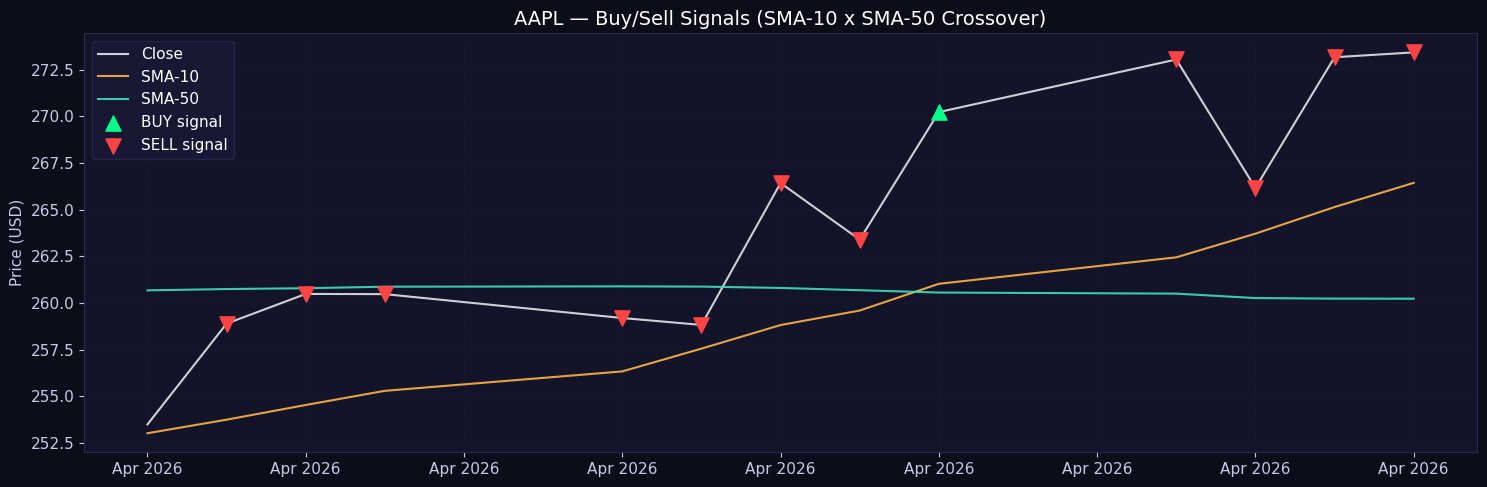

Total BUY signals : 1
Total SELL signals: 11


In [10]:
# ── CELL 10 — Buy / Sell Signals (SMA 10 crosses SMA 50) ─────────────────────
# EXPLAIN LIKE I AM 5:
# When the fast line (SMA-10) crosses ABOVE the slow line (SMA-50) = BUY signal
# When the fast line crosses BELOW the slow line = SELL signal

TICKER = 'AAPL'   # change to any ticker

df = q("""
    SELECT date, close, sma_10, sma_50
    FROM   price_with_metrics
    WHERE  ticker = :t AND sma_10 IS NOT NULL AND sma_50 IS NOT NULL
    ORDER  BY date
""", params={'t': TICKER})
df['date'] = pd.to_datetime(df['date'])
df['sma_10'] = df['sma_10'].astype(float)
df['sma_50'] = df['sma_50'].astype(float)
df['close']  = df['close'].astype(float)

# Detect crossovers
df['above'] = df['sma_10'] > df['sma_50']
df['signal'] = df['above'].diff()  # True = just crossed up, False = just crossed down
buys  = df[df['signal'] == True]
sells = df[df['signal'] == False]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['date'], df['close'],  color='#ffffff', lw=1.5, label='Close',  alpha=0.8)
ax.plot(df['date'], df['sma_10'], color='#ffb347', lw=1.5, label='SMA-10', alpha=0.9)
ax.plot(df['date'], df['sma_50'], color='#3de0c0', lw=1.5, label='SMA-50', alpha=0.9)

# Plot signals
ax.scatter(buys['date'],  buys['close'],  marker='^', color='#00ff88', s=120, zorder=5, label='BUY signal')
ax.scatter(sells['date'], sells['close'], marker='v', color='#ff4444', s=120, zorder=5, label='SELL signal')

ax.set_title(f'{TICKER} — Buy/Sell Signals (SMA-10 x SMA-50 Crossover)', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total BUY signals : {len(buys)}')
print(f'Total SELL signals: {len(sells)}')

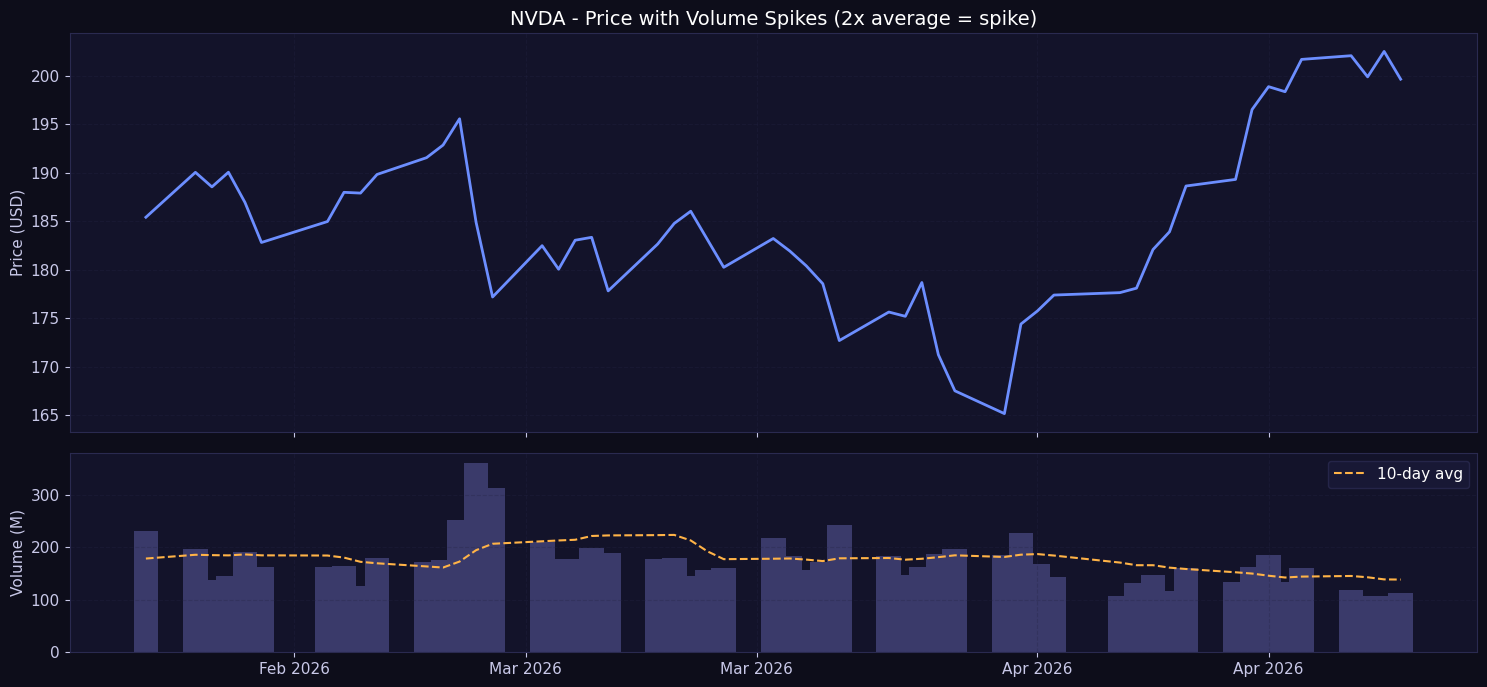

Volume spike days for NVDA: 0
Empty DataFrame
Columns: [date, close, volume]
Index: []


In [11]:
# ── CELL 11 — Volume Spike Detector ──────────────────────────────────────────
TICKER = 'NVDA'

df = q("""
    SELECT sp.date, sp.close, sp.volume,
           sm.volume_avg_10
    FROM   stock_prices sp
    JOIN   stock_metrics sm USING (ticker, date)
    WHERE  sp.ticker = :t AND sm.volume_avg_10 IS NOT NULL
    ORDER  BY sp.date
""", params={'t': TICKER})

df['date']          = pd.to_datetime(df['date'])
df['volume']        = df['volume'].astype(float)
df['volume_avg_10'] = df['volume_avg_10'].astype(float)
df['close']         = df['close'].astype(float)
df['spike']         = df['volume'] > (df['volume_avg_10'] * 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(df['date'], df['close'], color='#6c8eff', lw=2)
ax1.set_title(f'{TICKER} - Price with Volume Spikes (2x average = spike)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

colors = ['#ff4444' if s else '#3a3a6a' for s in df['spike']]
ax2.bar(df['date'], df['volume'] / 1e6, color=colors, width=1.5)
ax2.plot(df['date'], df['volume_avg_10'] / 1e6, color='#ffb347', lw=1.5,
         linestyle='--', label='10-day avg')
ax2.set_ylabel('Volume (M)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

spikes = df[df['spike']]
print(f'Volume spike days for {TICKER}: {len(spikes)}')
print(spikes[['date','close','volume']].tail(5).to_string(index=False))

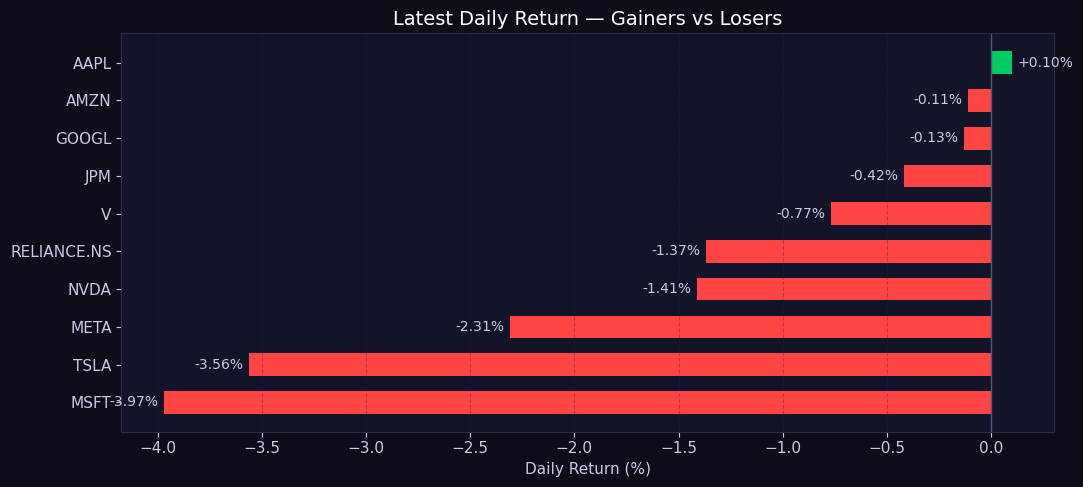

TOP GAINER : AAPL +0.1%
TOP LOSER  : MSFT -3.97%


In [12]:
# ── CELL 12 — Daily Top Gainers & Losers ─────────────────────────────────────
# EXPLAIN LIKE I AM 5:
# Which stocks went UP the most today? Which went DOWN the most?
# Like a leaderboard for your stocks.

gl = q("""
    SELECT lp.ticker,
           ROUND(lp.close::NUMERIC, 2)                        AS close,
           ROUND((sm.daily_return * 100)::NUMERIC, 2)         AS change_pct,
           ROUND((sm.rsi_14)::NUMERIC, 1)                     AS rsi
    FROM latest_prices lp
    LEFT JOIN stock_metrics sm USING (ticker, date)
    WHERE sm.daily_return IS NOT NULL
    ORDER BY sm.daily_return DESC
""")
gl['change_pct'] = gl['change_pct'].astype(float)

colors = ['#00cc66' if v >= 0 else '#ff4444' for v in gl['change_pct']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(gl['ticker'], gl['change_pct'], color=colors, height=0.6, edgecolor='none')
ax.bar_label(bars, fmt='%+.2f%%', padding=4, color='#c8c8e8', fontsize=10)
ax.axvline(0, color='#555577', linewidth=1)
ax.set_title('Latest Daily Return — Gainers vs Losers', fontsize=14)
ax.set_xlabel('Daily Return (%)')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('TOP GAINER :', gl.iloc[0]['ticker'],  f"+{gl.iloc[0]['change_pct']}%")
print('TOP LOSER  :', gl.iloc[-1]['ticker'], f"{gl.iloc[-1]['change_pct']}%")

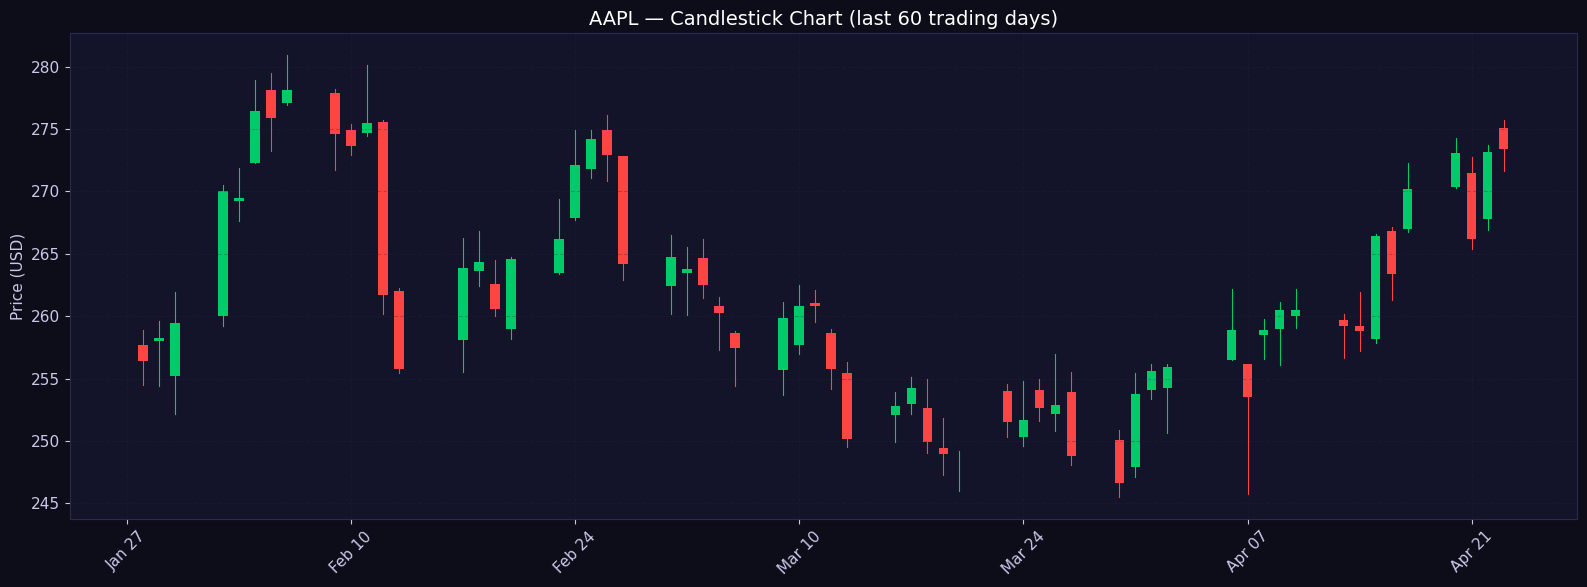

In [13]:
# ── CELL 13 — Candlestick OHLC Chart ─────────────────────────────────────────
# EXPLAIN LIKE I AM 5:
# Each candle = 1 day.
# GREEN candle = price went UP that day (close > open)
# RED candle   = price went DOWN that day (close < open)
# The thin line (wick) shows the highest and lowest price of the day.

TICKER = 'AAPL'    # change to any ticker
DAYS   = 60        # how many recent days to show

df = q("""
    SELECT date, open, high, low, close
    FROM   stock_prices
    WHERE  ticker = :t
    ORDER  BY date DESC
    LIMIT  :d
""", params={'t': TICKER, 'd': DAYS})
df = df.sort_values('date').reset_index(drop=True)
df['date']  = pd.to_datetime(df['date'])
for col in ['open','high','low','close']:
    df[col] = df[col].astype(float)

fig, ax = plt.subplots(figsize=(16, 6))

for i, row in df.iterrows():
    color = '#00cc66' if row['close'] >= row['open'] else '#ff4444'
    # Candle body
    ax.bar(row['date'],
           abs(row['close'] - row['open']),
           bottom=min(row['open'], row['close']),
           color=color, width=0.6, edgecolor='none')
    # Wick (high-low line)
    ax.plot([row['date'], row['date']], [row['low'], row['high']],
            color=color, linewidth=0.8)

ax.set_title(f'{TICKER} — Candlestick Chart (last {DAYS} trading days)', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()